In [63]:
import numpy as np
import sys
import time
import h5py
from tqdm import tqdm

import numpy as np
import re
from math import ceil
from sklearn.metrics import average_precision_score
from torch.utils.data import Dataset
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import pickle
#import pickle5 as pickle

from sklearn.model_selection import train_test_split

from scipy.sparse import load_npz
from glob import glob

from transformers import get_constant_schedule_with_warmup
from sklearn.metrics import precision_score,recall_score,accuracy_score

from src.train import trainModel
from src.dataloader import getData,spliceDataset,h5pyDataset,collate_fn, getDataPointListFull
from src.weight_init import keras_init
from src.losses import categorical_crossentropy_2d
from src.model import SpliceFormer, SpliceAI_10K
from src.evaluation_metrics import print_topl_statistics
import copy

In [2]:
data_dir = '../Data'
SL=5000
CL_max=40000
setType = 'test'
annotation_test, transcriptToLabel_test, seqData = getData(data_dir, setType) 

In [64]:
device = torch.device("cpu")
model_m = SpliceFormer(CL_max,determenistic=True, crop=False)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)
model_m = nn.DataParallel(model_m)
output_class_labels = ['Null', 'Acceptor', 'Donor']

n_models = 10

model_m.load_state_dict(torch.load('../Results/PyTorch_Models/transformer_encoder_40k_171022_3',map_location=device))
model_m.eval()


DataParallel(
  (module): SpliceFormer(
    (SpliceAI): SpliceAI(
      (conv_layer_1): Conv1d(4, 32, kernel_size=(1,), stride=(1,))
      (skip_layers): ModuleList(
        (0-4): 5 x Conv1d(32, 32, kernel_size=(1,), stride=(1,))
      )
      (res_layers): ModuleList(
        (0): ResComboBlock(
          (comboBlock): Sequential(
            (0): ResidualBlock(
              (convlayer1): Conv1d(32, 32, kernel_size=(11,), stride=(1,), padding=(5,))
              (convlayer2): Conv1d(32, 32, kernel_size=(11,), stride=(1,), padding=(5,))
              (activate): ReLU(inplace=True)
              (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
              (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.01, affine=True, track_running_stats=True)
              (shortcut): Identity()
            )
            (1): ResidualBlock(
              (convlayer1): Conv1d(32, 32, kernel_size=(11,), stride=(1,), padding=(5,))
              (convlayer2): Conv1d

In [4]:
BATCH_SIZE = 1
specific_anno = annotation_test[annotation_test['name'].apply(lambda x: x.split('--')[0])=='CFTR']

In [5]:
test_dataset = spliceDataset(getDataPointListFull(specific_anno,transcriptToLabel_test,SL,CL_max,shift=SL))
test_dataset.seqData = seqData
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
l = 1
for i,(batch_chunks,target_chunks) in enumerate(tqdm(test_loader)):
    batch_features = batch_chunks.to(torch.float32).to(device)      # shape: [1, 4, 45000]
    targets = torch.squeeze(target_chunks.to(torch.float32).to(device), dim=0)  # shape: [3, 45000]
    
    signal = batch_features[0].sum(dim=0)  # shape: [45000]
    nonzero_positions = torch.nonzero(signal > 0).squeeze()
    print("Transcript spans:", nonzero_positions.min().item(), "to", nonzero_positions.max().item())
    l += 1

    if l >1:
        break

  0%|          | 0/38 [00:00<?, ?it/s]/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
  0%|          | 0/38 [00:00<?, ?it/s]

Transcript spans: 20000 to 44999


In [12]:
cnn = (model_m.module.conv_final(model_m.module.SpliceAI(batch_features)))

In [65]:
# activation = {}
# gradient = {}
# def forward_hook(name):
#     def ahook(model, input, output):
#         activation[name] = output.detach()
#     return ahook

# def backward_hook(name):
#     def ghook(model, grad_input, grad_output):
#         gradient[name] = grad_output.detach()
#     return ghook

activations = []
gradients = []

# Hooks to capture activations and gradients
def forward_hook(model, input, output):
    activations.append(output)

def backward_hook(model, grad_input, grad_output):
    gradients.append(grad_output)

last_res_block = (model_m.module.SpliceAI.res_layers[3].comboBlock[-1].convlayer2)
print(last_res_block)

handle_forward = last_res_block.register_forward_hook(forward_hook)
handle_backward = last_res_block.register_full_backward_hook(backward_hook)

Conv1d(32, 32, kernel_size=(41,), stride=(1,), padding=(500,), dilation=(25,))


In [66]:
output = model_m(batch_features)
target = output[0][0,2,20184]
model_m.zero_grad()
target.backward()

RuntimeError: Output 0 of BackwardHookFunctionBackward is a view and is being modified inplace. This view was created inside a custom Function (or because an input was returned as-is) and the autograd logic to handle view+inplace would override the custom backward associated with the custom Function, leading to incorrect gradients. This behavior is forbidden. You can fix this by cloning the output of the custom Function.

In [43]:
activations = torch.mean(activations[0],dim=0)
gradients = torch.mean(gradients[0][0], dim=0)

In [56]:
avg_grad = torch.mean(gradients, dim=1)

weighted_activations = avg_grad.unsqueeze(1) * activations
grad_cam = torch.sum(weighted_activations, dim=0)
relu = torch.nn.ReLU()
grad_cam = relu(grad_cam)
grad_cam = grad_cam.detach().numpy()
grad_cam /= grad_cam.max()

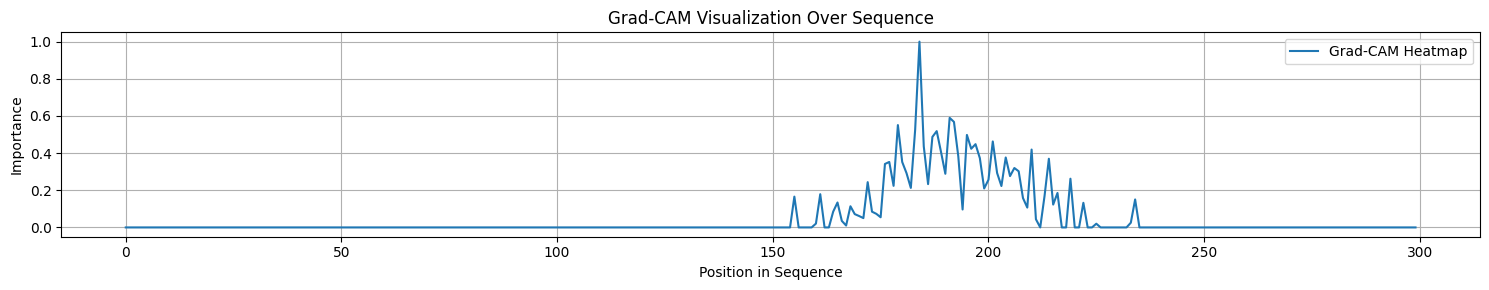

In [59]:
shift = 0
import matplotlib.pyplot as plt
import numpy as np
donor_idx = torch.nonzero(targets[2,:]).numpy() - shift
# gradcam_map is your 1D heatmap (shape: [45000])
plt.figure(figsize=(15, 3))
plt.plot(grad_cam[20000:20300], label='Grad-CAM Heatmap')
# plt.scatter(donor_idx, np.ones(len(donor_idx)),c='green',marker="^", clip_on=False, zorder=10,label='Donor')

plt.xlabel('Position in Sequence')
plt.ylabel('Importance')
plt.title('Grad-CAM Visualization Over Sequence')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

handle_forward.remove()
handle_backward.remove()
model_m.zero_grad()
for param in model_m.parameters():
    param.grad = None
